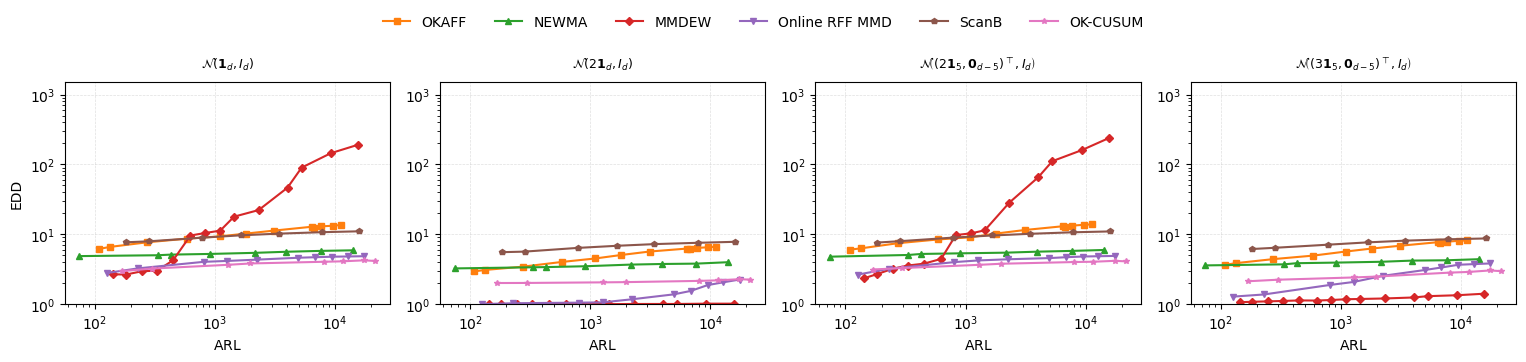

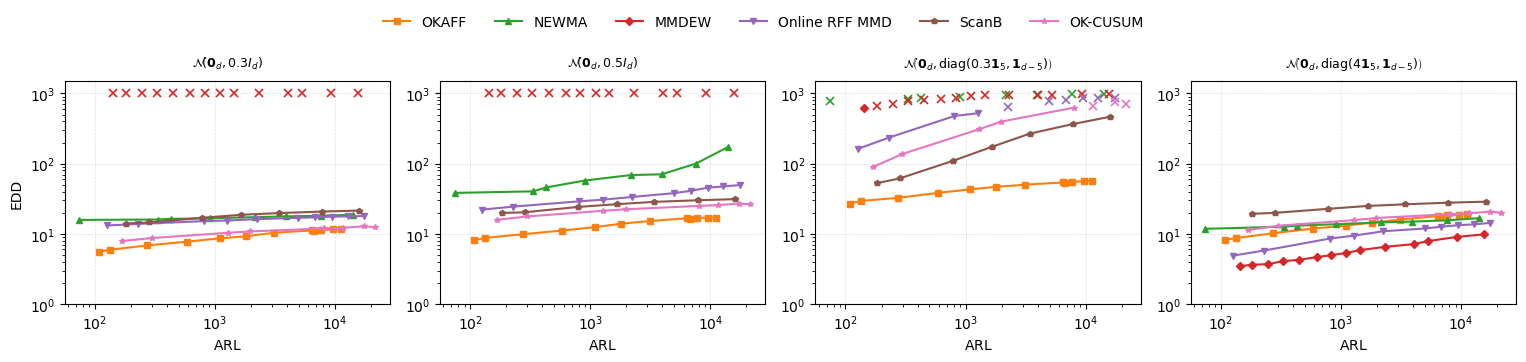

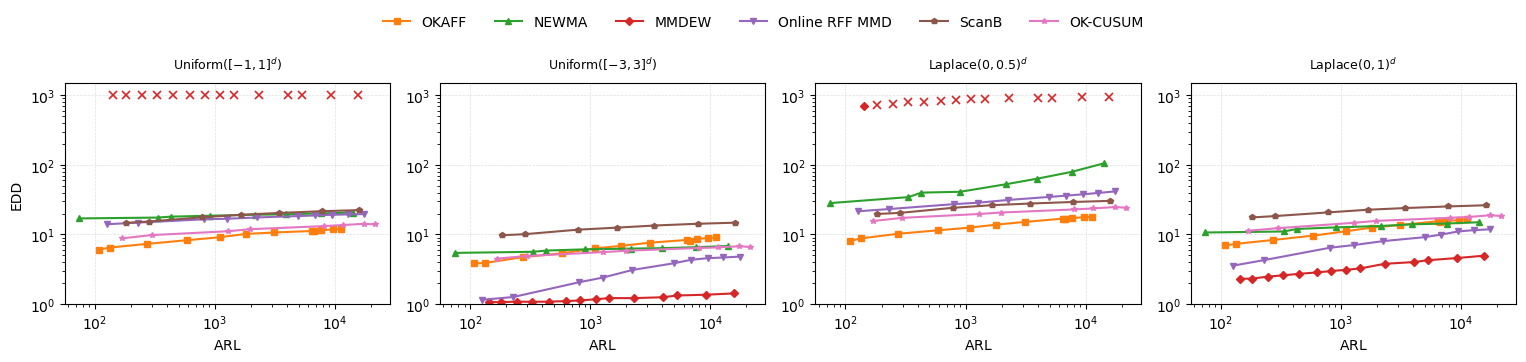

Loaded 2,065 rows across 6 group(s).
Saved row PDFs:
arl_edd_d20_3rows/edd_vs_arl_dense_sparse_mean_shifts_d20.pdf
arl_edd_d20_3rows/edd_vs_arl_dense_sparse_variance_shifts_d20_short.pdf
arl_edd_d20_3rows/edd_vs_arl_uniform_laplace_d20_short.pdf


In [ ]:
import math
import textwrap
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterMathtext, LogLocator, NullFormatter


@dataclass(frozen=True)
class SourceConfig:
    path: str
    group: str


SOURCES = [
    SourceConfig("OKAFF-ARL-EDD-d20.csv", "OKAFF"),
    SourceConfig("NEWMA-EDD-d20.csv", "NEWMA"),
    SourceConfig("MMDEW-EDD-d20.csv", "MMDEW"),
    SourceConfig("online_rff_mmd-EDD-d20.csv", "Online RFF MMD"),
    SourceConfig("Scanb-EDD-d20.csv", "ScanB"),
    SourceConfig("okcusum-EDD-d20.csv", "OK-CUSUM"),
]


COLUMN_ALIASES = {
    "data": ["post_change_name", "scenario", "data_name", "data"],
    "ARL_hat": ["arl_hat", "ARL_hat"],
    "EDD": ["edd_hat", "EDD_hat", "EDD"],
    "censor_rate": [
        "edd_censored_rate", "edd_censor_rate", "EDD_censor_rate", "censor_rate",
    ],
    "tuning": ["threshold", "chart_L", "tuning", "tau", "alpha", "lambda", "kappa", "L", "k"],
}


DATA_ORDER = [
    "MeanShift(mu=1)", "MeanShift(mu=2)",
    "MeanShift(first5coord=2.0)", "MeanShift(first5coord=3.0)",

    "CovDiag(var=0.3)", "CovDiag(var=0.5)",
    "CovDiag(first5var=0.3)", "CovDiag(first5var=4)",

    "Uniform(scale=1.0)", "Uniform(scale=3.0)",
    "Laplace(scale=0.5)", "Laplace(scale=1.0)",
]

TITLE_MAP = {
    "MeanShift(mu=1)": r"$\mathcal{N}(\mathbf{1}_d,I_d)$",
    "MeanShift(mu=2)": r"$\mathcal{N}(2\mathbf{1}_d,I_d)$",
    "MeanShift(first5coord=2.0)": r"$\mathcal{N}\!\left((2\mathbf{1}_5,\mathbf{0}_{d-5})^\top,I_d\right)$",
    "MeanShift(first5coord=3.0)": r"$\mathcal{N}\!\left((3\mathbf{1}_5,\mathbf{0}_{d-5})^\top,I_d\right)$",
    "CovDiag(var=0.3)": r"$\mathcal{N}\!\left(\mathbf{0}_d,0.3I_d\right)$",
    "CovDiag(var=0.5)": r"$\mathcal{N}\!\left(\mathbf{0}_d,0.5I_d\right)$",
    "CovDiag(first5var=0.3)": r"$\mathcal{N}\!\left(\mathbf{0}_d,\operatorname{diag}(0.3\mathbf{1}_5,\mathbf{1}_{d-5})\right)$",
    "CovDiag(first5var=4)": r"$\mathcal{N}\!\left(\mathbf{0}_d,\operatorname{diag}(4\mathbf{1}_5,\mathbf{1}_{d-5})\right)$",
    "Uniform(scale=1.0)": r"$\operatorname{Uniform}([-1,1]^d)$",
    "Uniform(scale=3.0)": r"$\operatorname{Uniform}([-3,3]^d)$",
    "Laplace(scale=0.5)": r"$\operatorname{Laplace}(0,0.5)^d$",
    "Laplace(scale=1.0)": r"$\operatorname{Laplace}(0,1)^d$",
}

GROUPS = ["OKAFF", "NEWMA", "MMDEW", "Online RFF MMD", "ScanB", "OK-CUSUM"]

COLOR_MAP = {
    "OKAFF": "tab:orange",
    "NEWMA": "tab:green",
    "MMDEW": "tab:red",
    "Online RFF MMD": "tab:purple",
    "ScanB": "tab:brown",
    "OK-CUSUM": "tab:pink",
}

MARKER_MAP = {
    "OKAFF": "s",
    "NEWMA": "^",
    "MMDEW": "D",
    "Online RFF MMD": "v",
    "ScanB": "p",
    "OK-CUSUM": "*",
}

CENSOR_CROSS_RATE = 0.40
Y_TOP_PADDING_FACTOR = 1.50


def first_existing_column(df, candidates):
    return next((col for col in candidates if col in df.columns), None)


def standardize_source(source):
    path = Path(source.path)
    if not path.exists():
        print(f"Warning: {source.path} not found. Skipping {source.group}.")
        return None

    df = pd.read_csv(path)
    rename_map = {}

    for target, aliases in COLUMN_ALIASES.items():
        col = first_existing_column(df, aliases)
        if col is not None and col != target:
            rename_map[col] = target

    df = df.rename(columns=rename_map)

    required = {"data", "ARL_hat", "EDD"}
    missing = sorted(required - set(df.columns))
    if missing:
        print(f"Warning: {path.name} missing {missing}. Skipping {source.group}.")
        return None

    if "censor_rate" not in df.columns:
        df["censor_rate"] = 0.0
    if "tuning" not in df.columns:
        df["tuning"] = np.nan

    df["data"] = df["data"].astype(str).str.strip()
    df["Group"] = source.group
    return df


def load_results(sources=SOURCES):
    frames = []
    for source in sources:
        df = standardize_source(source)
        if df is not None:
            frames.append(df)

    if not frames:
        raise FileNotFoundError("No usable CSV files were found.")

    df = pd.concat(frames, ignore_index=True, sort=False)
    df.columns = df.columns.str.strip()

    df["Group"] = df["Group"].astype(str).str.strip()
    for col in ["ARL_hat", "EDD", "censor_rate"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["data", "Group", "ARL_hat", "EDD"])
    df = df[(df["ARL_hat"] > 0) & (df["EDD"] > 0)]
    df = df[~df["data"].str.contains("StandardNormal", na=False)]
    return df.copy()


def wrap_title(s, width=28):
    return "\n".join(textwrap.wrap(str(s), width=width))



def postchange_row_name(row_datas, row_idx):
    """Return the filename for each row in the short comparison."""
    if row_datas and all(name.startswith("MeanShift(") for name in row_datas):
        return "edd_vs_arl_dense_sparse_mean_shifts_d20.pdf"
    if row_datas and all(name.startswith("CovDiag(") for name in row_datas):
        return "edd_vs_arl_dense_sparse_variance_shifts_d20_short.pdf"
    if row_datas and all(name.startswith(("Uniform(", "Laplace(")) for name in row_datas):
        return "edd_vs_arl_uniform_laplace_d20_short.pdf"
    return f"edd_vs_arl_row{row_idx:02d}_d20_short.pdf"


def plot_panel(ax, df, dname, y_limits, legend_handles, show_ylabel=False):
    sub_all = df[df["data"] == dname]

    for group in GROUPS:
        sub = sub_all[sub_all["Group"] == group].sort_values("ARL_hat")
        if sub.empty:
            continue

        low = sub["censor_rate"].fillna(0) < CENSOR_CROSS_RATE
        if low.any():
            line, = ax.plot(
                sub.loc[low, "ARL_hat"],
                sub.loc[low, "EDD"],
                marker=MARKER_MAP[group],
                color=COLOR_MAP[group],
                linewidth=1.5,
                markersize=4,
                label=group,
            )
            legend_handles.setdefault(group, line)

        if (~low).any():
            ax.plot(
                sub.loc[~low, "ARL_hat"],
                sub.loc[~low, "EDD"],
                linestyle="None",
                marker="x",
                color=COLOR_MAP[group],
                markersize=6,
                markeredgewidth=1.2,
            )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(*y_limits)

    ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1.0,)))
    ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    ax.yaxis.set_minor_formatter(NullFormatter())

    title = TITLE_MAP.get(dname, wrap_title(dname))
    ax.set_title(title, fontsize=9, pad=10)
    ax.set_xlabel(r"$\mathrm{ARL}$", fontsize=10)
    if show_ylabel:
        ax.set_ylabel("EDD", fontsize=10)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)


def save_row_plots(df, output_dir="row_pdfs", ncols=4, include_unlisted=False):
    present = set(df["data"].unique())
    datas = [name for name in DATA_ORDER if name in present]
    if include_unlisted:
        datas.extend(sorted(present - set(datas)))

    if not datas:
        raise ValueError("No scenarios matched DATA_ORDER.")

    positive_edd = df.loc[df["EDD"] > 0, "EDD"]
    y_limits = (
        10 ** math.floor(math.log10(positive_edd.min())),
        (10 ** math.ceil(math.log10(positive_edd.max()))) * Y_TOP_PADDING_FACTOR,
    )

    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    saved_paths = []
    for row_idx, start in enumerate(range(0, len(datas), ncols), start=1):
        row_datas = datas[start:start + ncols]
        fig, axes = plt.subplots(1, ncols, figsize=(4.0 * ncols, 3.8), squeeze=False)
        axes = axes.ravel()
        legend_handles = {}

        for col_idx, ax in enumerate(axes):
            if col_idx < len(row_datas):
                plot_panel(
                    ax,
                    df,
                    row_datas[col_idx],
                    y_limits,
                    legend_handles,
                    show_ylabel=(col_idx == 0),
                )
            else:
                ax.axis("off")

        legend_groups = [g for g in GROUPS if g in legend_handles]
        if legend_groups:
            fig.legend(
                [legend_handles[g] for g in legend_groups],
                legend_groups,
                loc="upper center",
                bbox_to_anchor=(0.5, 0.98),
                ncol=len(legend_groups),
                frameon=False,
                fontsize=10,
            )

        fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.88])

        out_path = output_dir / postchange_row_name(row_datas, row_idx)
        fig.savefig(out_path, bbox_inches="tight")
        saved_paths.append(out_path)

        plt.show()
        plt.close(fig)

    return saved_paths


dfp = load_results()
saved_paths = save_row_plots(dfp, output_dir="arl_edd_d20_3rows")

print(f"Loaded {len(dfp):,} rows across {dfp['Group'].nunique()} group(s).")
print("Saved row PDFs:")
for path in saved_paths:
    print(path)